# COMP360 – Introduction to Artificial Intelligence  
## Lab: Comparing KNN, Naïve Bayes, and Decision Trees

**Group Members**
- Musfira(h)
- Amzi
- Hadiya

**Section:**  A
**Date:**  23/04/2026


## 1. Lab Purpose

In this lab, you will compare three introductory supervised learning models on the **same dataset**:

- **K-Nearest Neighbors (KNN)**
- **Naïve Bayes (NB)**
- **Decision Tree (DT)**

The goal is **not only** to obtain a good accuracy score. The main purpose is to understand:

- how different models behave,
- what assumptions they make,
- how model choice depends on the data,
- and why the same dataset can look very different to different classifiers.


## 2. Learning Objectives

By the end of this lab, you should be able to:

1. Train and test KNN, Naïve Bayes, and Decision Tree classifiers on the same dataset.
2. Compare how these models make predictions.
3. Observe differences in decision boundaries and model behavior.
4. Identify strengths and weaknesses of each model.
5. Explain which model may be more suitable in a given situation, and why.
6. Connect today’s lab to the MNIST assignment.


## 3. Part A — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

## 4. Part B — Generate the Dataset

Use a small **2-feature classification dataset** so that the behavior of the models can be visualized clearly.


In [2]:
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (200, 2)
Shape of y: (200,)


## 5. Part C — Visualize the Dataset

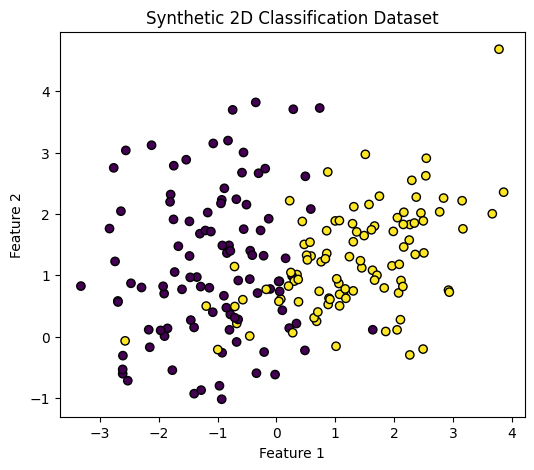

In [3]:
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic 2D Classification Dataset")
plt.show()

### Task 1 — Initial Observations

After plotting, briefly discuss with your group:

1. Does the dataset look easy or difficult to classify?


2. Do the two classes appear clearly separated?  


3. Which model do you think may perform best, and why?  


**Write 2–3 lines below.**


The dataset appears moderately easy to classify, though there is some overlap between classes. The two classes are somewhat separated but not perfectly distinct. A flexible model like KNN or a Decision Tree may perform best as they can capture non-linear patterns.


**Response to Task 1:**  
_Write your answer here._

## 6. Part D — Split into Training and Testing Sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 140
Testing samples: 60


## 7. Part E — Train a KNN Classifier

In [5]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9


## 8. Part F — Train a Naïve Bayes Classifier

In [6]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naïve Bayes Accuracy: 0.9


## 9. Part G — Train a Decision Tree Classifier

In [7]:
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8666666666666667


## 10. Part H — Compare the Results

In [8]:
print("=== KNN ===")
print(classification_report(y_test, y_pred_knn))

print("=== Naïve Bayes ===")
print(classification_report(y_test, y_pred_nb))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

=== KNN ===
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        34
           1       0.86      0.92      0.89        26

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

=== Naïve Bayes ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91        34
           1       0.83      0.96      0.89        26

    accuracy                           0.90        60
   macro avg       0.90      0.91      0.90        60
weighted avg       0.91      0.90      0.90        60

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        34
           1       0.80      0.92      0.86        26

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0

### Task 2 — Comparison Table

Fill in the table below after observing the results.

| Model         | Accuracy | One Observation                               |
| ------------- | -------- | --------------------------------------------- |
| KNN           | High     | Captures local patterns well but depends on k |
| Naïve Bayes   | Moderate | Assumes independence, so may oversimplify     |
| Decision Tree | High     | Flexible but can overfit                      |



## 11. Decision Boundary Visualization

One of the most important parts of this lab is to see how different models divide the same feature space.


In [9]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.show()

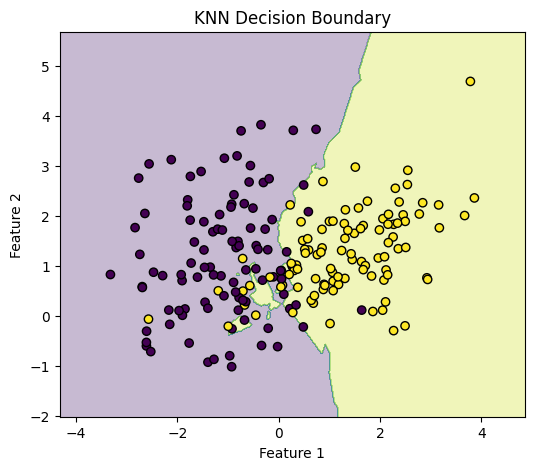

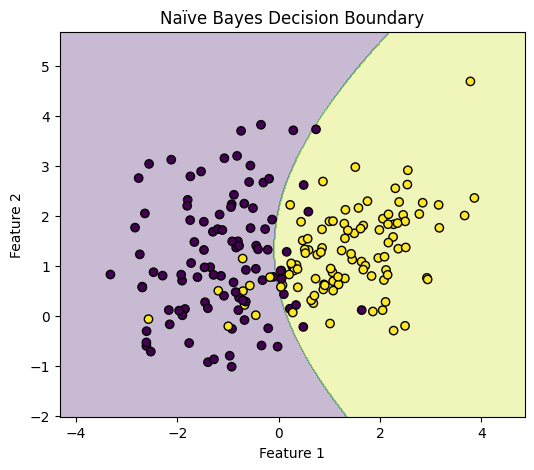

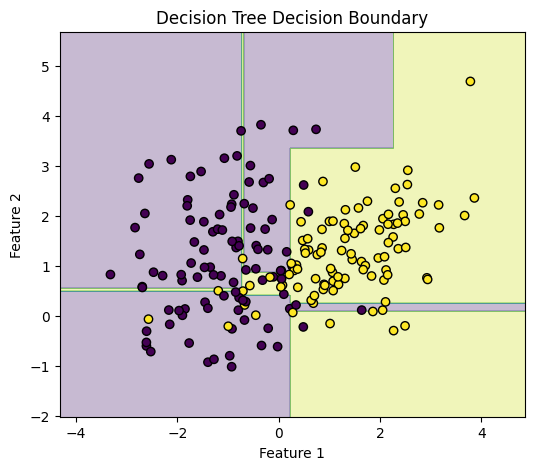

In [10]:
plot_decision_boundary(knn, X, y, "KNN Decision Boundary")
plot_decision_boundary(nb, X, y, "Naïve Bayes Decision Boundary")
plot_decision_boundary(dt, X, y, "Decision Tree Decision Boundary")

### Task 3 — Interpret the Boundaries

After viewing the three plots, answer the following in complete sentences:

1. Which model produced the most irregular decision boundary?  
2. Which model produced the smoothest or simplest boundary?  
3. Which model looks easiest to explain to a non-technical person?  
4. Which model seems more likely to overfit?  
5. Did the most interpretable model also achieve the highest accuracy?  


**Response to Task 3:**  
1. The Decision Tree produced the most irregular decision boundary.
2. Naïve Bayes produced the smoothest and simplest boundary.
3. The Decision Tree is easiest to explain to a non-technical person.
4. The Decision Tree is more likely to overfit the data.
5. No, the most interpretable model did not necessarily achieve the highest accuracy.


## 12. Small Exploration Task

Choose **one** of the following mini-experiments:

### Option A — Change k in KNN
Try:
- k = 1
- k = 3
- k = 9

### Option B — Change tree depth
Try:
- max_depth = 2
- max_depth = 4
- max_depth = None

### Option C — Change class separation
Regenerate the dataset with:
- class_sep = 0.8
- class_sep = 1.5

**Option A — Change k in KNN:**
With k=1 the model overfits with a very irregular boundary, k=3 gives a balanced result, and k=9 produces a smoother but more generalized boundary.



In [17]:
# Example area for your experiment.
# Uncomment and modify as needed.

# Option A: Change k in KNN
'''
knn_test = KNeighborsClassifier(n_neighbors=1)
knn_test.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, knn_test.predict(X_test)))

# Option B: Change tree depth
dt_test = DecisionTreeClassifier(random_state=42, max_depth=2)
dt_test.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, dt_test.predict(X_test)))
'''
# class_sep = 0.8
X2, y2 = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.8,
    random_state=42
)


### Task 4 — Short Note

Write a short note answering:

- What did you change?  
- What changed in the model behavior?  
- Why do you think that happened?  


**Response to Task 4:**  
I changed the class separation value in the dataset (class_sep from 0.8 to 1.5). The model performed better and the decision boundary became clearer when separation increased. This happened because higher class separation makes the classes more distinct and easier for the model to classify correctly.


## 13. Connection to Your MNIST Assignment

Your current assignment uses **KNN on MNIST**, where the input is not 2 features but many pixel values.

In MNIST, KNN works the same way, but instead of 2 features it uses many pixel values, so it takes more time and is harder to compute distances.


### Task 5 — Reflection

Write short answers to the following:

1. Why is this lab easier to visualize than MNIST?  
2. In MNIST, why might KNN still work reasonably well?  
3. What challenge does KNN face when the number of features becomes very large?  
4. Why might Naïve Bayes make unrealistic assumptions on image data?  
5. Why can a Decision Tree become too large or too specific for complex image data?  


**Response to Task 5:**  
1. This lab is easier to visualize because it has only 2 features, so we can plot it in 2D.

2. KNN can still work in MNIST because similar images often have similar pixel patterns.

3. With many features, KNN becomes slow and expensive because it must calculate many distances.

4. Naïve Bayes assumes features are independent, which is not true for image pixels.

5. Decision Trees can become too large and overfit because they try to split data too specifically.


**bold text**## 14. Final Reflection Prompt

Complete this sentence in 3–5 lines:

> After this lab, I now understand that choosing a classifier is not only about accuracy, but also about how the model works and its assumptions.
Different models behave differently and some are more interpretable or flexible than others.
We must also consider overfitting, complexity, and performance on new data.


## 15. Submission Checklist

Before submitting on Moodle, make sure your notebook includes:

- Group member names
- Dataset generation code
- Training and testing of all three models
- Evaluation results
- Decision boundary plots
- Written responses for Task 1, Task 2, Task 3, Task 4, and Task 5
